In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import EngFormatter
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.colors import LogNorm, Normalize
from matplotlib import cm, gridspec, ticker
import matplotlib.patches as patches
import pandas as pd
import seaborn as sns
import bioframe as bf
import cooler
from coolpuppy import coolpup
import cooltools
from coolpuppy.lib.numutils import get_enrichment
import warnings
import utils

In [2]:
# !cooler zoomify --balance -r 200000 -o G523_Johnson_200k.cool ../glioblastoma/G523/G523_inter_30.mcool::/resolutions/10000

In [20]:
clr_path = { 
   "GSC": "data/G1.200k.cool",
    # "G523_Johnson": "G523_Johnson_200k.cool", 
   "Neuron": "neuron_200k.cool", 
 "G523_Johnson": "G523_Johnson_200k.cool", }
cts = list(clr_path.keys()) 

In [21]:
def plot_hic_reg_zoom_out(clr, reg, ax, vmin, vmax, snips=None, title=None):
    # Create custom colormap
    cmap_colors = np.array([
        [255, 255, 255, 255],
        [245, 166, 35, 255],
        [208, 2, 27, 255],
        [0, 0, 0, 255]
    ]) / 255
    cmap_nodes = [0, 0.35, 0.6, 1]
    cust_cmap = LinearSegmentedColormap.from_list("mycmap", list(zip(cmap_nodes, cmap_colors)))
    
    # Plot heatmap
    chrom, start, end = reg
    im = ax.matshow(
        clr.matrix(balance=True).fetch(reg),
        norm=LogNorm(vmin=vmin, vmax=vmax),
        cmap=cust_cmap,
        extent=(start, end, end, start), 
        interpolation=None,
    );
    
    # Set title
    if title:
        ax.set_title(title)
    
    format_ticks_zoom_out(ax)
    
    # Draw rectangles
    if snips:
        for j, (reg1, reg2) in enumerate(snips):
            rect = patches.Rectangle(
                (reg2[1], reg1[1]), reg2[2]-reg2[1], reg1[2]-reg1[1], 
                edgecolor='k', facecolor='none', linewidth=1
            )
            ax.add_patch(rect)
    
    # Draw colorbar
    cb = plt.colorbar(im, ax=ax, shrink=0.5, location='right')
    cb.set_ticks([])
    cb.ax.set_ylabel('Contact probability', rotation=270, fontsize=8)
    
    return

In [22]:
def format_ticks_zoom_out(ax, base=2e7, x=True, y=True, rotate=True):
    bp_formatter = ticker.EngFormatter('b')
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
        ax.yaxis.set_major_locator(ticker.MultipleLocator(base))
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(base))
        ax.xaxis.tick_bottom()

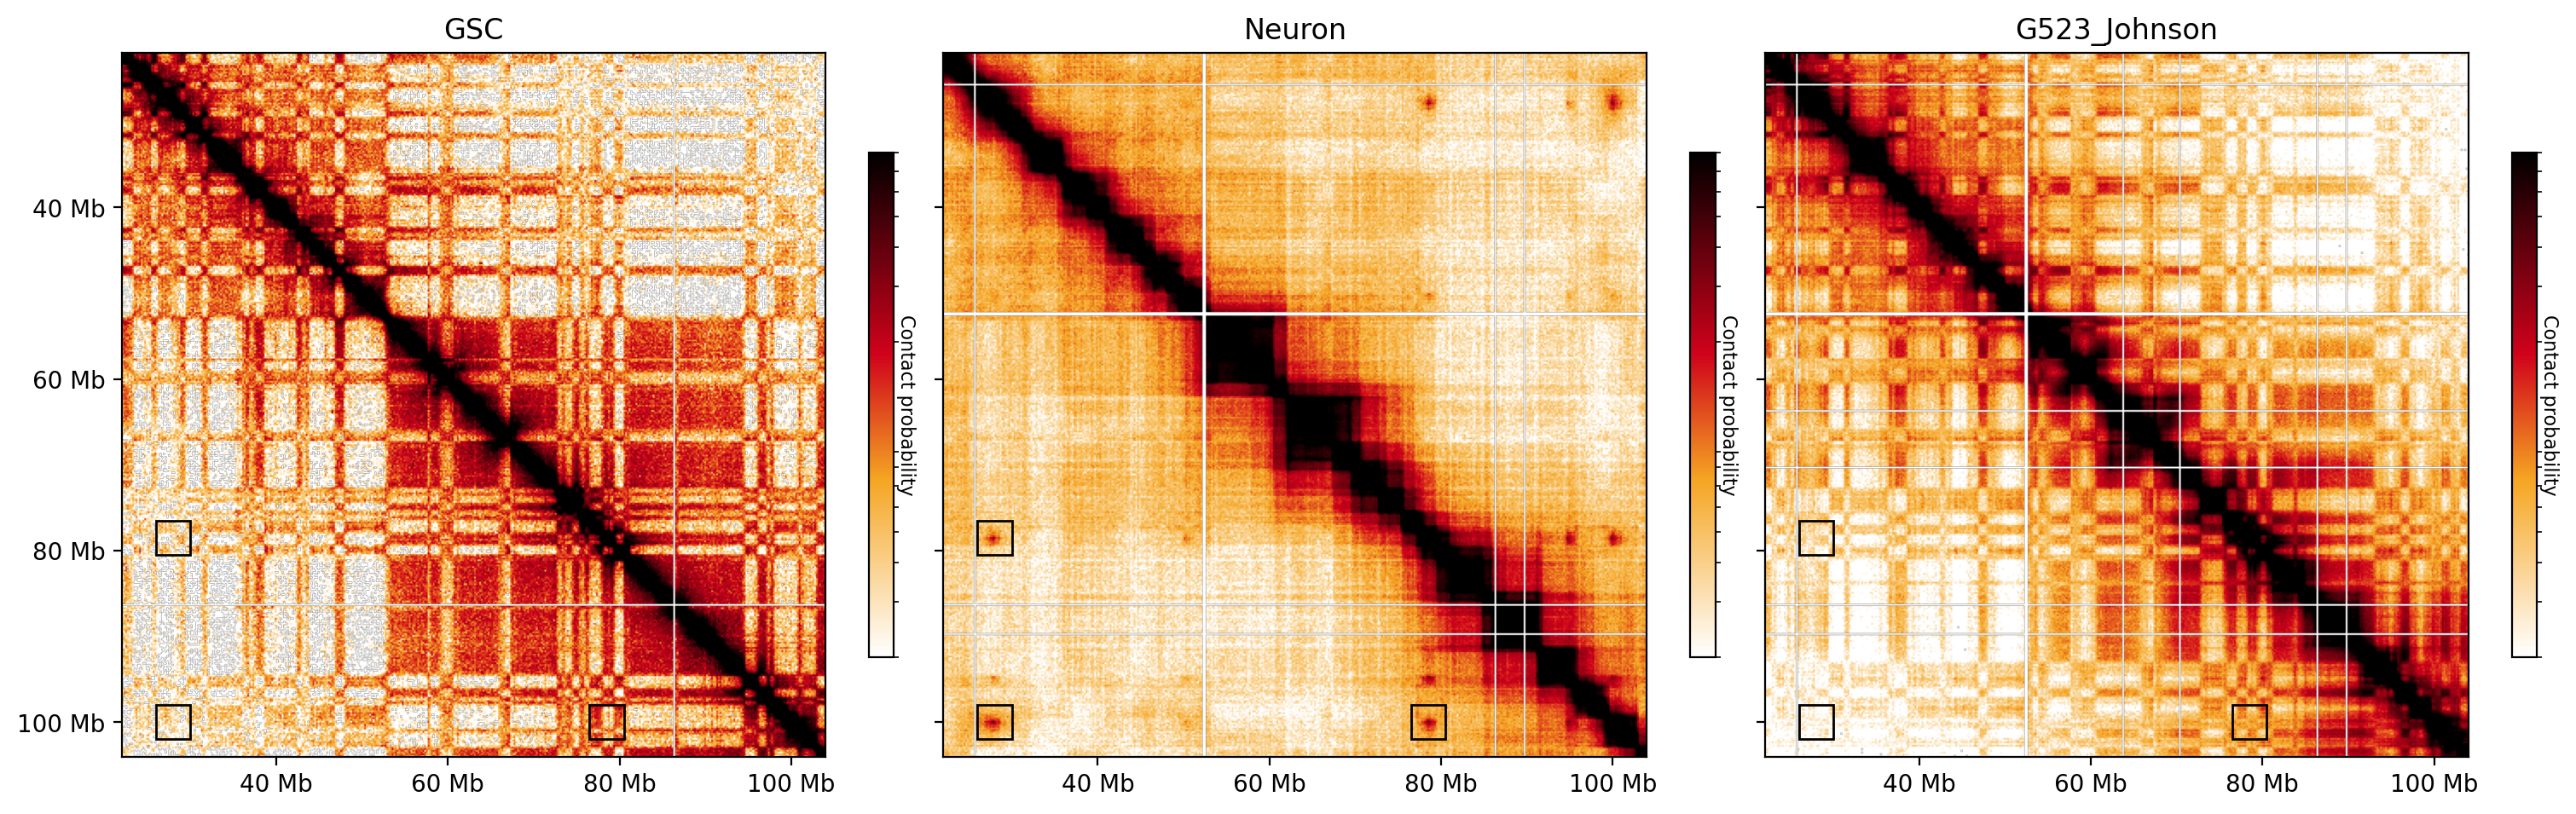

In [24]:
## Plot zoom-out
res = 200_000 # Hi-C resolution
clrs = {ct: cooler.Cooler(clr_path[ct] + f'::resolutions/{res}') 
        for ct in cts}

# Select snips to zoom-in
snips = [[['chr13', 76_500_000, 80_500_000],  ['chr13', 26_000_000, 30_000_000]], 
         [['chr13', 98_000_000, 102_000_000], ['chr13', 26_000_000, 30_000_000]], 
         [['chr13', 98_000_000, 102_000_000], ['chr13', 76_500_000, 80_500_000]]]

# Draw heatmaps
f, axs = plt.subplots(1, 3, dpi=200, figsize=(15, 6), sharey=True, constrained_layout=True)

for i, ct in enumerate(cts):
    plot_hic_reg_zoom_out(
        clrs[ct], 
        reg=('chr13', 22_000_000, 104_000_000), 
        ax=axs[i], vmin=0.0002, vmax=0.008, 
        snips=snips, title=ct
    )